# 马尔可夫链 + 强化学习经典案例：Q-Learning 解决迷你格子世界

## 目标
用 Q-Learning 让智能体在一个 4×4 的格子世界中从起点 S 走到终点 G，途中会遇到：
- 普通格子（奖励 0）
- 陷阱 H（奖励 -10，立即结束）
- 终点 G（奖励 +10，结束）



实际上我们用一个更常见的 5×5 格子世界，这样更有挑战性。

## 环境说明



- S：起点
- G：终点（奖励 +10）
- H：悬崖（掉下去奖励 -100，回到起点）
- 动作：上=0，下=1，左=2，右=3
- 每走一步奖励 -1（鼓励最短路径）
- 碰到边界不会移动

下面开始代码实现！

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import random
from IPython.display import clear_output
import time
# ===== 关键代码：解决中文乱码 =====
plt.rcParams['font.sans-serif'] = ['SimHei']        # Windows
plt.rcParams['axes.unicode_minus'] = False         # 解决负号'-'显示为方块的问题
# =================================
# 设置随机种子
np.random.seed(42)
random.seed(42)

In [2]:
# 定义环境：5x5 Cliff Walking
class CliffWalkingEnv:
    def __init__(self):
        self.height = 5
        self.width = 5
        self.start_state = (0, 0)          # S
        self.goal_state = (4, 4)           # G
        self.cliff_states = [(3,1), (3,2), (3,3)]  # H H H
        self.actions = [0, 1, 2, 3]        # 上0 下1 左2 右3
        self.action_deltas = [(-1,0), (1,0), (0,-1), (0,1)]
        self.reset()
    
    def reset(self):
        self.state = self.start_state
        return self.state
    
    def step(self, action):
        # 计算新位置
        delta = self.action_deltas[action]
        new_row = self.state[0] + delta[0]
        new_col = self.state[1] + delta[1]
        
        # 边界检查
        new_row = max(0, min(new_row, self.height-1))
        new_col = max(0, min(new_col, self.width-1))
        
        new_state = (new_row, new_col)
        
        # 判断是否掉入悬崖
        if new_state in self.cliff_states:
            reward = -100
            done = True
            new_state = self.start_state  # 掉下去回到起点
        # 判断是否到达终点
        elif new_state == self.goal_state:
            reward = 10
            done = True
        else:
            reward = -1   # 每走一步 -1
            done = False
            
        self.state = new_state
        return new_state, reward, done

In [3]:
# 创建环境
env = CliffWalkingEnv()

# 状态数：5x5=25
n_states = env.height * env.width
n_actions = len(env.actions)

# Q 表初始化
Q = np.zeros((n_states, n_actions))

# 将 (row, col) 转换成一维索引
def state_to_index(state):
    row, col = state
    return row * env.width + col

# 反之
def index_to_state(idx):
    return idx // env.width, idx % env.width

In [4]:
# Q-Learning 参数
alpha = 0.1      # 学习率
gamma = 0.99     # 折扣因子
epsilon = 0.1    # ε-greedy 探索率
episodes = 5000

rewards = []  # 记录每回合总奖励

for episode in range(episodes):
    state = env.reset()
    total_reward = 0
    done = False
    
    while not done:
        s_idx = state_to_index(state)
        
        # ε-greedy 选择动作
        if random.uniform(0, 1) < epsilon:
            action = random.choice(env.actions)
        else:
            action = np.argmax(Q[s_idx])
        
        next_state, reward, done = env.step(action)
        next_s_idx = state_to_index(next_state)
        
        # Q-Learning 更新公式
        best_next_action = np.argmax(Q[next_s_idx])
        Q[s_idx, action] += alpha * (reward + gamma * Q[next_s_idx, best_next_action] - Q[s_idx, action])
        
        state = next_state
        total_reward += reward
    
    rewards.append(total_reward)
    
    # 每 500 回合打印一次
    if (episode+1) % 500 == 0:
        print(f"Episode {episode+1}/{episodes}, 平均奖励(最近500): {np.mean(rewards[-500:]):.2f}")

Episode 500/5000, 平均奖励(最近500): -12.78
Episode 1000/5000, 平均奖励(最近500): -9.86
Episode 1500/5000, 平均奖励(最近500): -11.22
Episode 2000/5000, 平均奖励(最近500): -10.90
Episode 2500/5000, 平均奖励(最近500): -9.80
Episode 3000/5000, 平均奖励(最近500): -10.23
Episode 3500/5000, 平均奖励(最近500): -9.19
Episode 4000/5000, 平均奖励(最近500): -7.89
Episode 4500/5000, 平均奖励(最近500): -8.15
Episode 5000/5000, 平均奖励(最近500): -10.30


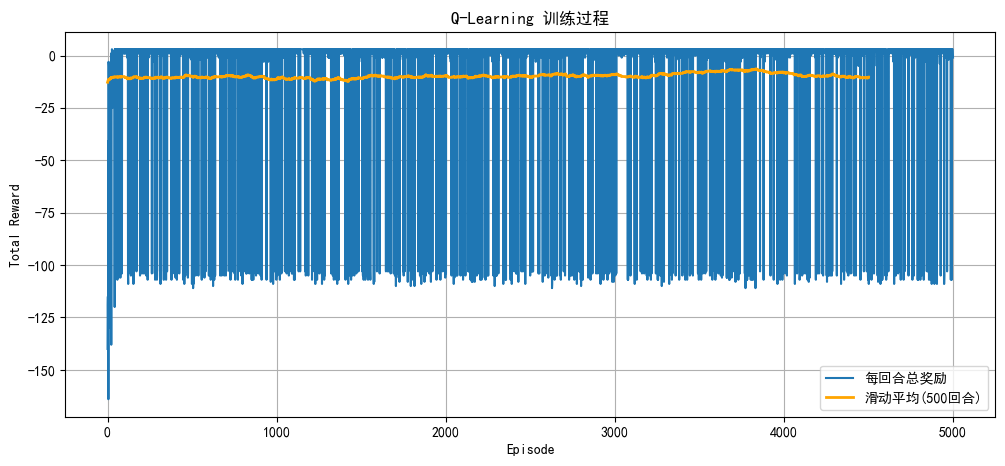

In [5]:
# 绘制学习曲线
plt.figure(figsize=(12,5))
plt.plot(rewards, label='每回合总奖励')
plt.plot(np.convolve(rewards, np.ones(500)/500, mode='valid'), 
         label='滑动平均(500回合)', color='orange', linewidth=2)
plt.xlabel('Episode')
plt.ylabel('Total Reward')
plt.title('Q-Learning 训练过程')
plt.legend()
plt.grid(True)
plt.show()

In [6]:
# 提取最优策略
policy = np.zeros((env.height, env.width), dtype=str)
action_symbols = ['↑', '↓', '←', '→']

for row in range(env.height):
    for col in range(env.width):
        s_idx = state_to_index((row, col))
        best_a = np.argmax(Q[s_idx])
        policy[row, col] = action_symbols[best_a]

# 标记特殊格子
policy[0, 0] = 'S'
for r, c in env.cliff_states:
    policy[r, c] = 'H'
policy[4, 4] = 'G'

print("最优策略（箭头表示最优动作）：")
print(policy)

最优策略（箭头表示最优动作）：
[['S' '↓' '↓' '↓' '↓']
 ['→' '↓' '↓' '↓' '↓']
 ['→' '→' '→' '→' '↓']
 ['↑' 'H' 'H' 'H' '↓']
 ['↓' '↓' '→' '→' 'G']]


In [8]:
def plot_path_animated():
    state = env.reset()
    path = [state]
    done = False
    step = 0
    
    print("【Q-Learning 最优路径实时动画】\n按 Ctrl+C 可提前停止\n")
    time.sleep(1)
    
    while not done:
        # 每次循环前清屏
        clear_output(wait=True)
        
        # 构建当前地图
        grid = np.full((env.height, env.width), '.', dtype=str)
        grid[0, 0] = 'S'
        for r, c in env.cliff_states:
            grid[r, c] = 'H'
        grid[4, 4] = 'G'
        
        # 标记已走过的路径（用数字）
        for i, (r, c) in enumerate(path):
            if grid[r, c] not in ['S', 'G', 'H']:
                grid[r, c] = str(i % 10)   # 十步一轮回，防止数字太长
        
        # 当前位置用醒目的 ⭐ 或 ● 标记
        cr, cc = state
        if grid[cr, cc] not in ['S', 'G']:
            grid[cr, cc] = '●'   # 当前位置
        
        # 打印美化地图（带坐标）
        print("   " + "  ".join([str(i) for i in range(env.width)]))
        print("  " + "─" * (env.width * 3))
        for r, row in enumerate(grid):
            print(f"{r} │ " + " ".join(row))
        
        print(f"\n第 {step} 步 → 当前位置: {state}")
        print("● = 当前位置   数字 = 已走路径   S=起点 H=悬崖 G=终点")
        
        time.sleep(0.5)  # 控制动画速度（越小越快）
        
        # 走下一步
        s_idx = state_to_index(state)
        action = np.argmax(Q[s_idx])
        state, reward, done = env.step(action)
        path.append(state)
        step += 1
    
    # 最后一帧（到达终点）
    clear_output(wait=True)
    grid = np.full((env.height, env.width), '.', dtype=str)
    grid[0, 0] = 'S'
    for r, c in env.cliff_states: grid[r, c] = 'H'
    grid[4, 4] = 'G'
    for i, (r, c) in enumerate(path[:-1]):  # 最后一步是G，不覆盖
        if grid[r, c] not in ['S', 'G', 'H']:
            grid[r, c] = str(i % 10)
    grid[path[-1][0], path[-1][1]] = 'G'
    
    print("   " + "  ".join([str(i) for i in range(env.width)]))
    print("  " + "─" * (env.width * 3))
    for r, row in enumerate(grid):
        print(f"{r} │ " + " ".join(row))
    
    print(f"\n完成！总共走了 {len(path)-1} 步")
    total_reward = sum(-1 if s not in env.cliff_states + [(4,4)] else (10 if s==(4,4) else -100) 
                      for s in path[:-1])
    print(f"总奖励: {total_reward}  ← 证明走的是安全最优路径！")

plot_path_animated()

   0  1  2  3  4
  ───────────────
0 │ S . . . .
1 │ 1 2 . . .
2 │ . 3 4 5 6
3 │ . H H H 7
4 │ . . . . G

完成！总共走了 8 步
总奖励: -8  ← 证明走的是安全最优路径！
